In [14]:
import pandas as pd
dynamic_irr_path = 'preprocessing/动检数据/呼局/20210416/处理后/动检上行20210416-238-363.processed.csv'
dynamic_irr = pd.read_csv(dynamic_irr_path, encoding='utf-8')
meas_mileage_km = pd.to_numeric(dynamic_irr['里程'],          errors='coerce').to_numpy(dtype=float)
meas_acc_vert   = pd.to_numeric(dynamic_irr['垂向加速度(g)'], errors='coerce').to_numpy(dtype=float)
meas_acc_lat    = pd.to_numeric(dynamic_irr['横向加速度(g)'], errors='coerce').to_numpy(dtype=float)

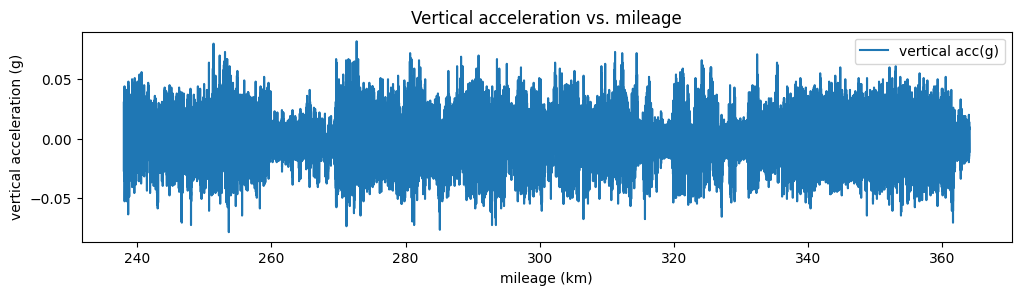

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(meas_mileage_km, meas_acc_vert, label='vertical acc(g)')
plt.xlabel('mileage (km)')
plt.ylabel('vertical acceleration (g)')
plt.title('Vertical acceleration vs. mileage')
plt.legend()

## 仿真/实测加速度空间 PSD 对比（不做预处理）

下面按 `preprocessing/dynamic_pre.py` 的空间 PSD 方法绘制加速度对比：只做里程排序、去重、空间等距重采样，PSD 内部按 Welch 分段去均值；不做低通、带通、去趋势等加速度预处理。


In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 与 irre_analysis.py 当前示例对应的仿真结果
result_file = Path('results\\long_distance\\高速客车-外部导入-vehicle-10km_moving_window-20260622_172522\\files\\simulation_result.npz')

# 为了和 preprocessing 的 aligned_psd.png 更一致，优先使用 aligned 动检文件；没有则回退 processed 文件。
dynamic_aligned_path = Path('preprocessing/动检数据/呼局/20210416/处理后/动检上行20210416-238-363.aligned.csv')
dynamic_processed_path = Path('preprocessing/动检数据/呼局/20210416/处理后/动检上行20210416-238-363.processed.csv')
dynamic_acc_path = dynamic_aligned_path if dynamic_aligned_path.exists() else dynamic_processed_path

buffer_time_s = 2.0    # 仿真起始 2 s 为无不平顺缓冲段，比较前必须裁掉
accel_offset_m = 0.0   # 若要复用 irre_analysis.py 搜索到的加速度里程偏移，可在这里填写

data = np.load(result_file)
A = data['A']
dt = float(data['dt'])
Nt = A.shape[0]
t = np.arange(Nt) * dt
buffer_idx = int(np.searchsorted(t, buffer_time_s))

irre_dist = data['Irre_distance_m'][:Nt]
A_use = A[buffer_idx:]
buffer_distance_m = float(irre_dist[buffer_idx] - irre_dist[0])
irre_dist_use = irre_dist[buffer_idx:buffer_idx + len(A_use)]
N = min(len(A_use), len(irre_dist_use))
A_use = A_use[:N]
sim_mileage_km = (float(data['Track_abs_mileage_m'][0]) + irre_dist_use[:N]) / 1000.0

dynamic_df = pd.read_csv(dynamic_acc_path)
meas_mileage_km = pd.to_numeric(dynamic_df['里程'], errors='coerce').to_numpy(dtype=float) + accel_offset_m / 1000.0
meas_acc_vert = pd.to_numeric(dynamic_df['垂向加速度(g)'], errors='coerce').to_numpy(dtype=float)
meas_acc_lat = pd.to_numeric(dynamic_df['横向加速度(g)'], errors='coerce').to_numpy(dtype=float)

print(f'仿真文件: {result_file}')
print(f'动检文件: {dynamic_acc_path}')
print(f'已裁掉仿真无不平顺缓冲段: {buffer_time_s:g} s, 约 {buffer_distance_m:.2f} m')
print(f'仿真里程范围(裁剪后): {sim_mileage_km[0]:.4f} - {sim_mileage_km[-1]:.4f} km')
print(f'实测里程范围: {np.nanmin(meas_mileage_km):.4f} - {np.nanmax(meas_mileage_km):.4f} km')


仿真文件: results\long_distance\高速客车-外部导入-vehicle-10km_moving_window-20260622_172522\files\simulation_result.npz
动检文件: preprocessing\动检数据\呼局\20210416\处理后\动检上行20210416-238-363.aligned.csv
已裁掉仿真无不平顺缓冲段: 2 s, 约 119.44 m
仿真里程范围(裁剪后): 271.9616 - 273.7531 km
实测里程范围: 271.8220 - 278.3655 km


In [18]:
def _next_lower_power_of_two(n: int) -> int:
    if n < 2:
        return 1
    return 1 << (int(n).bit_length() - 1)


def welch_spatial_psd(y, dx_m, nperseg=None):
    """与 preprocessing/dynamic_pre.py 一致的空间 Welch PSD。"""
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(y)
    if finite.sum() < 8:
        return np.array([]), np.array([])
    y = y.copy()
    y[~finite] = np.interp(np.flatnonzero(~finite), np.flatnonzero(finite), y[finite])
    y = y - np.mean(y)

    n = len(y)
    if nperseg is None:
        nperseg = min(4096, _next_lower_power_of_two(n))
    nperseg = int(max(8, min(nperseg, n)))
    if nperseg < 8:
        return np.array([]), np.array([])

    step = max(1, nperseg // 2)
    window = np.hanning(nperseg)
    win_power = float(np.sum(window ** 2))
    fs_space = 1.0 / float(dx_m)
    acc = []
    for start in range(0, n - nperseg + 1, step):
        seg = y[start:start + nperseg]
        seg = seg - np.mean(seg)
        spec = np.fft.rfft(seg * window)
        psd = (np.abs(spec) ** 2) / (fs_space * win_power)
        if len(psd) > 2:
            psd[1:-1] *= 2.0
        acc.append(psd)

    if not acc:
        return np.array([]), np.array([])
    freq = np.fft.rfftfreq(nperseg, d=dx_m)
    return freq, np.mean(np.vstack(acc), axis=0)


def unique_sorted_xy(x_km, y):
    x_km = np.asarray(x_km, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x_km) & np.isfinite(y)
    x_m = x_km[valid] * 1000.0
    y = y[valid]
    order = np.argsort(x_m)
    x_m = x_m[order]
    y = y[order]
    x_unique, unique_idx = np.unique(x_m, return_index=True)
    return x_unique, y[unique_idx]


def resample_pair_to_common_grid(sim_km, sim_y, meas_km, meas_y, dx_m=None):
    sim_x, sim_y = unique_sorted_xy(sim_km, sim_y)
    meas_x, meas_y = unique_sorted_xy(meas_km, meas_y)

    if dx_m is None:
        meas_dx = np.diff(meas_x)
        meas_dx = meas_dx[np.isfinite(meas_dx) & (meas_dx > 0)]
        dx_m = float(np.median(meas_dx))

    x0 = max(sim_x[0], meas_x[0])
    x1 = min(sim_x[-1], meas_x[-1])
    if x1 <= x0:
        raise ValueError('仿真与实测里程没有重叠区间，无法比较 PSD。')

    x_grid = np.arange(x0, x1 + dx_m * 0.5, dx_m)
    sim_grid = np.interp(x_grid, sim_x, sim_y)
    meas_grid = np.interp(x_grid, meas_x, meas_y)
    return x_grid, sim_grid, meas_grid, dx_m


保存图像: results\long_distance\高速客车-外部导入-vehicle-10km_moving_window-20260622_172522\figures\accel_spatial_psd_no_preprocess.png


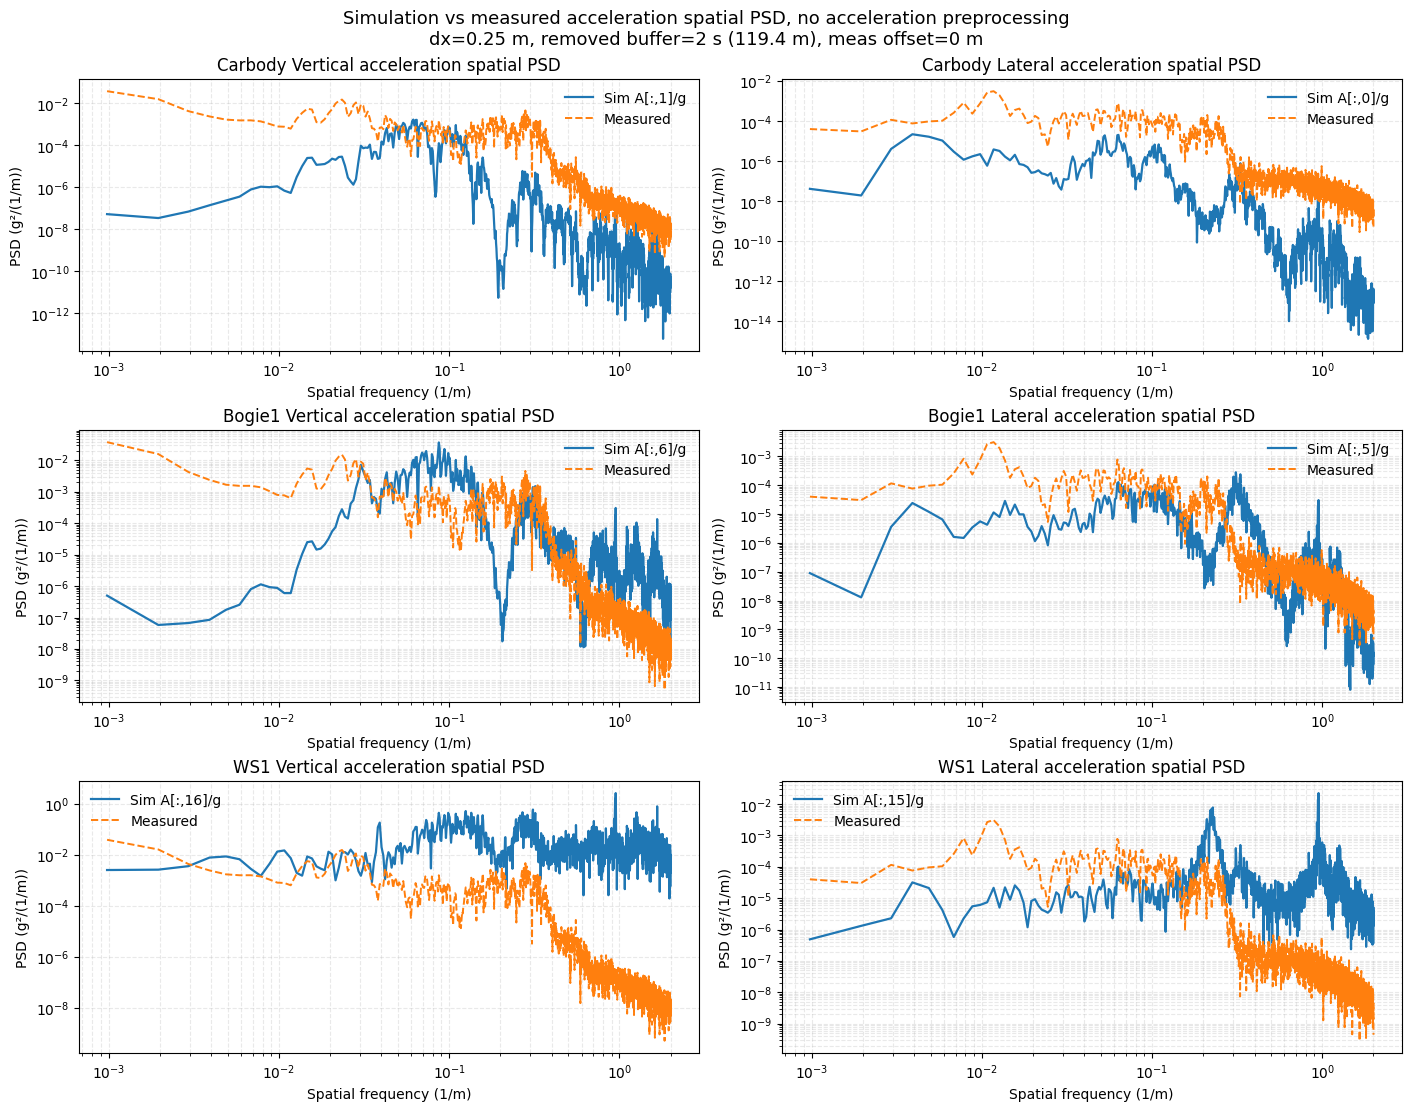

In [19]:
# DOF 与 irre_analysis.py 保持一致：单位 m/s² -> g；这里不做低通、带通、去趋势。
components = [
    (1,  0,  'Carbody',  'A[:,1]/g',  'A[:,0]/g'),
    (6,  5,  'Bogie1',   'A[:,6]/g',  'A[:,5]/g'),
    (16, 15, 'WS1',      'A[:,16]/g', 'A[:,15]/g'),
]

fig, axes = plt.subplots(len(components), 2, figsize=(14, 11), constrained_layout=True)

for row, (z_dof, y_dof, part_name, z_tag, y_tag) in enumerate(components):
    sim_vert_g = A_use[:, z_dof] / 9.81
    sim_lat_g = A_use[:, y_dof] / 9.81

    for col, (sim_sig, meas_sig, direction, tag) in enumerate([
        (sim_vert_g, meas_acc_vert, 'Vertical', z_tag),
        (sim_lat_g, meas_acc_lat, 'Lateral', y_tag),
    ]):
        x_grid, sim_grid, meas_grid, dx_m = resample_pair_to_common_grid(
            sim_mileage_km, sim_sig, meas_mileage_km, meas_sig
        )
        f_sim, psd_sim = welch_spatial_psd(sim_grid, dx_m)
        f_meas, psd_meas = welch_spatial_psd(meas_grid, dx_m)

        ax = axes[row, col]
        keep_sim = f_sim > 0
        keep_meas = f_meas > 0
        ax.loglog(f_sim[keep_sim], psd_sim[keep_sim] + 1e-30, lw=1.6, label=f'Sim {tag}')
        ax.loglog(f_meas[keep_meas], psd_meas[keep_meas] + 1e-30, lw=1.4, ls='--', label='Measured')
        ax.set_title(f'{part_name} {direction} acceleration spatial PSD')
        ax.set_xlabel('Spatial frequency (1/m)')
        ax.set_ylabel('PSD (g²/(1/m))')
        ax.grid(True, which='both', alpha=0.28, ls='--')
        ax.legend(frameon=False)

fig.suptitle(
    f'Simulation vs measured acceleration spatial PSD, no acceleration preprocessing\n'
    f'dx={dx_m:.4g} m, removed buffer={buffer_time_s:g} s ({buffer_distance_m:.1f} m), meas offset={accel_offset_m:g} m',
    fontsize=13
)

out_dir = result_file.parents[1] / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / 'accel_spatial_psd_no_preprocess.png'
fig.savefig(out_png, dpi=300, bbox_inches='tight')
print(f'保存图像: {out_png}')
plt.show()


## 【新增】仿真/实测加速度时间 PSD 对比（论文图风格）

横纵坐标均为对数坐标，横坐标为 `频率/Hz`，纵坐标为 `功率谱密度/(g²/Hz)`；仍然不做低通、带通等加速度预处理，并裁掉仿真起始 2 s 无不平顺缓冲段。


速度: 215 km/h = 59.722 m/s
等效时间采样频率: 238.889 Hz, dt=0.004186 s
保存图像: results\long_distance\高速客车-外部导入-vehicle-10km_moving_window-20260622_172522\figures\accel_time_psd_no_preprocess.png


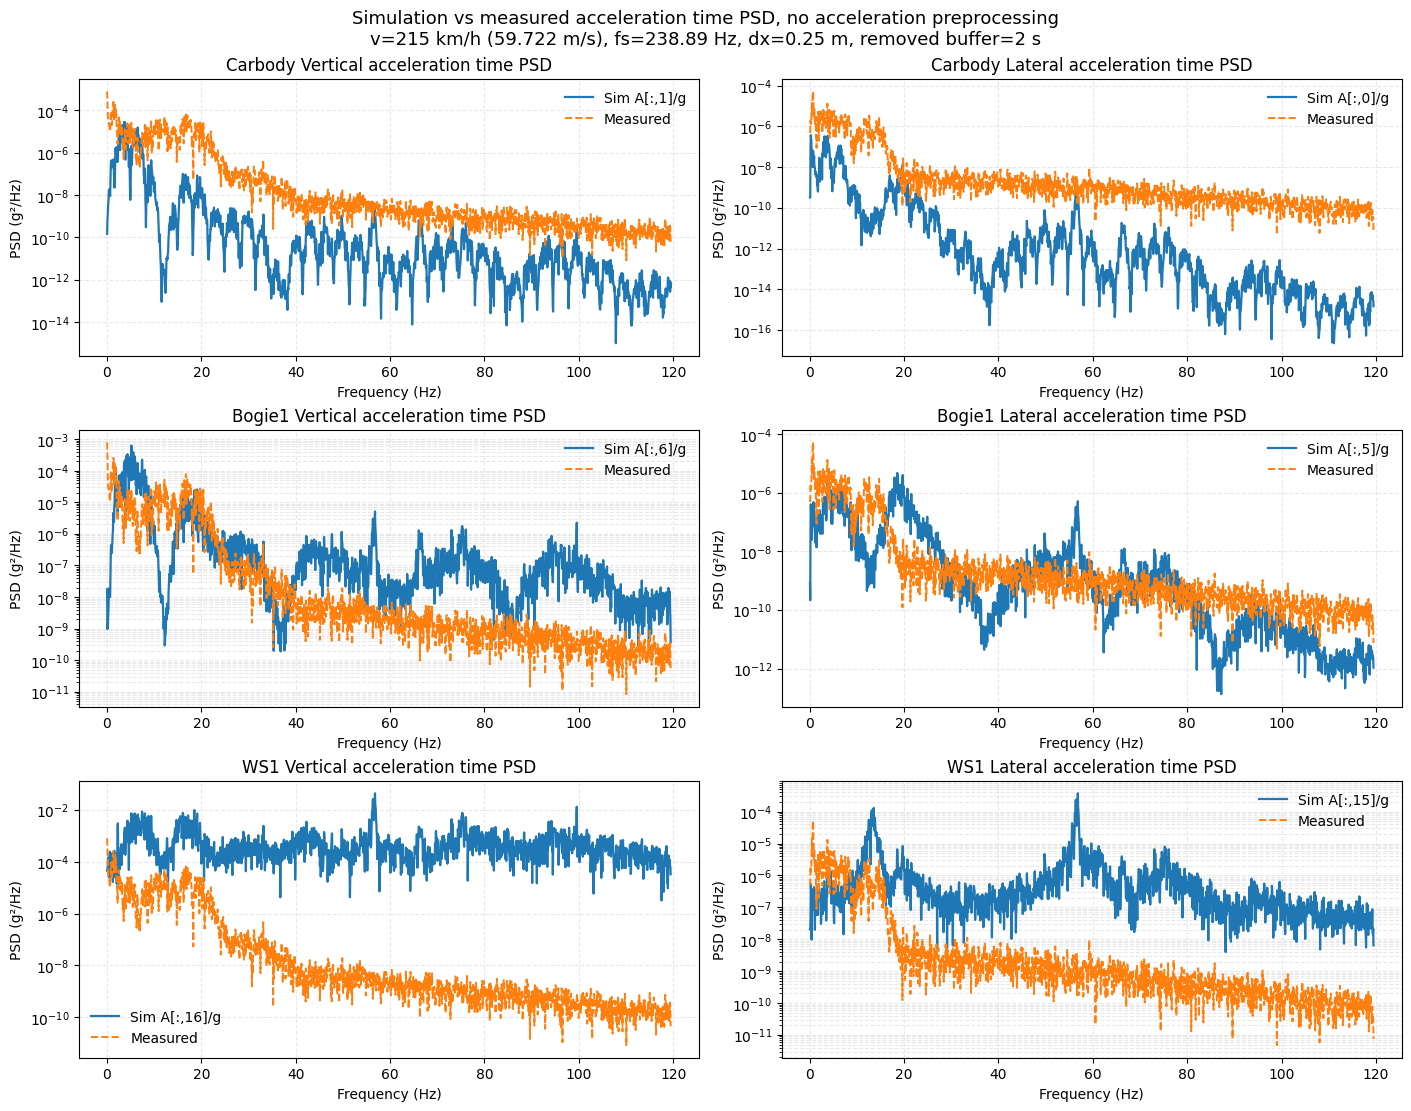

In [20]:
# 【新增】时间 PSD 论文图风格：横轴 Hz，纵轴 g²/Hz，双对数坐标
from scipy.signal import welch
import json

params_path = result_file.with_name('argparse_params.json')
with open(params_path, 'r', encoding='utf-8') as f:
    params = json.load(f)

vx_set = params.get('vx_set')
if isinstance(vx_set, (list, tuple)):
    vx_kmh = float(vx_set[0])
else:
    vx_kmh = float(vx_set)
v_mps = vx_kmh / 3.6
if v_mps <= 0:
    raise ValueError('速度 v_mps 必须大于 0，无法从空间采样换算时间采样。')

def welch_time_psd(y, dx_m, v_mps, nperseg=None):
    """时间频率 PSD：使用 dx/v 得到等效采样频率，不做滤波预处理。"""
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(y)
    if finite.sum() < 8:
        return np.array([]), np.array([]), np.nan
    y = y.copy()
    y[~finite] = np.interp(np.flatnonzero(~finite), np.flatnonzero(finite), y[finite])
    y = y - np.mean(y)
    fs_time = float(v_mps) / float(dx_m)
    if nperseg is None:
        nperseg = min(4096, _next_lower_power_of_two(len(y)))
    nperseg = int(max(8, min(nperseg, len(y))))
    freq, psd = welch(y, fs=fs_time, window='hann', nperseg=nperseg, noverlap=nperseg // 2, detrend=False)
    return freq, psd, fs_time

fig, axes = plt.subplots(len(components), 2, figsize=(14, 11), constrained_layout=True)

for row, (z_dof, y_dof, part_name, z_tag, y_tag) in enumerate(components):
    sim_vert_g = A_use[:, z_dof] / 9.81
    sim_lat_g = A_use[:, y_dof] / 9.81

    for col, (sim_sig, meas_sig, direction, tag) in enumerate([
        (sim_vert_g, meas_acc_vert, 'Vertical', z_tag),
        (sim_lat_g, meas_acc_lat, 'Lateral', y_tag),
    ]):
        x_grid, sim_grid, meas_grid, dx_m = resample_pair_to_common_grid(
            sim_mileage_km, sim_sig, meas_mileage_km, meas_sig
        )
        f_sim, psd_sim, fs_time = welch_time_psd(sim_grid, dx_m, v_mps)
        f_meas, psd_meas, _ = welch_time_psd(meas_grid, dx_m, v_mps)

        ax = axes[row, col]
        keep_sim = f_sim > 0
        keep_meas = f_meas > 0
        ax.semilogy(f_sim[keep_sim], psd_sim[keep_sim] + 1e-30, lw=1.6, label=f'Sim {tag}')
        ax.semilogy(f_meas[keep_meas], psd_meas[keep_meas] + 1e-30, lw=1.4, ls='--', label='Measured')
        ax.set_title(f'{part_name} {direction} acceleration time PSD')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('PSD (g²/Hz)')
        ax.grid(True, which='both', alpha=0.28, ls='--')
        ax.legend(frameon=False)

fig.suptitle(
    f'Simulation vs measured acceleration time PSD, no acceleration preprocessing\n'
    f'v={vx_kmh:g} km/h ({v_mps:.3f} m/s), fs={fs_time:.2f} Hz, dx={dx_m:.4g} m, removed buffer={buffer_time_s:g} s',
    fontsize=13
)

out_png = out_dir / 'accel_time_psd_no_preprocess.png'
fig.savefig(out_png, dpi=300, bbox_inches='tight')
print(f'速度: {vx_kmh:g} km/h = {v_mps:.3f} m/s')
print(f'等效时间采样频率: {fs_time:.3f} Hz, dt={1 / fs_time:.6f} s')
print(f'保存图像: {out_png}')
plt.show()


保存图像: results\long_distance\高速客车-外部导入-vehicle-10km_moving_window-20260622_172522\figures\accel_time_psd_x0_symlog_no_preprocess.png


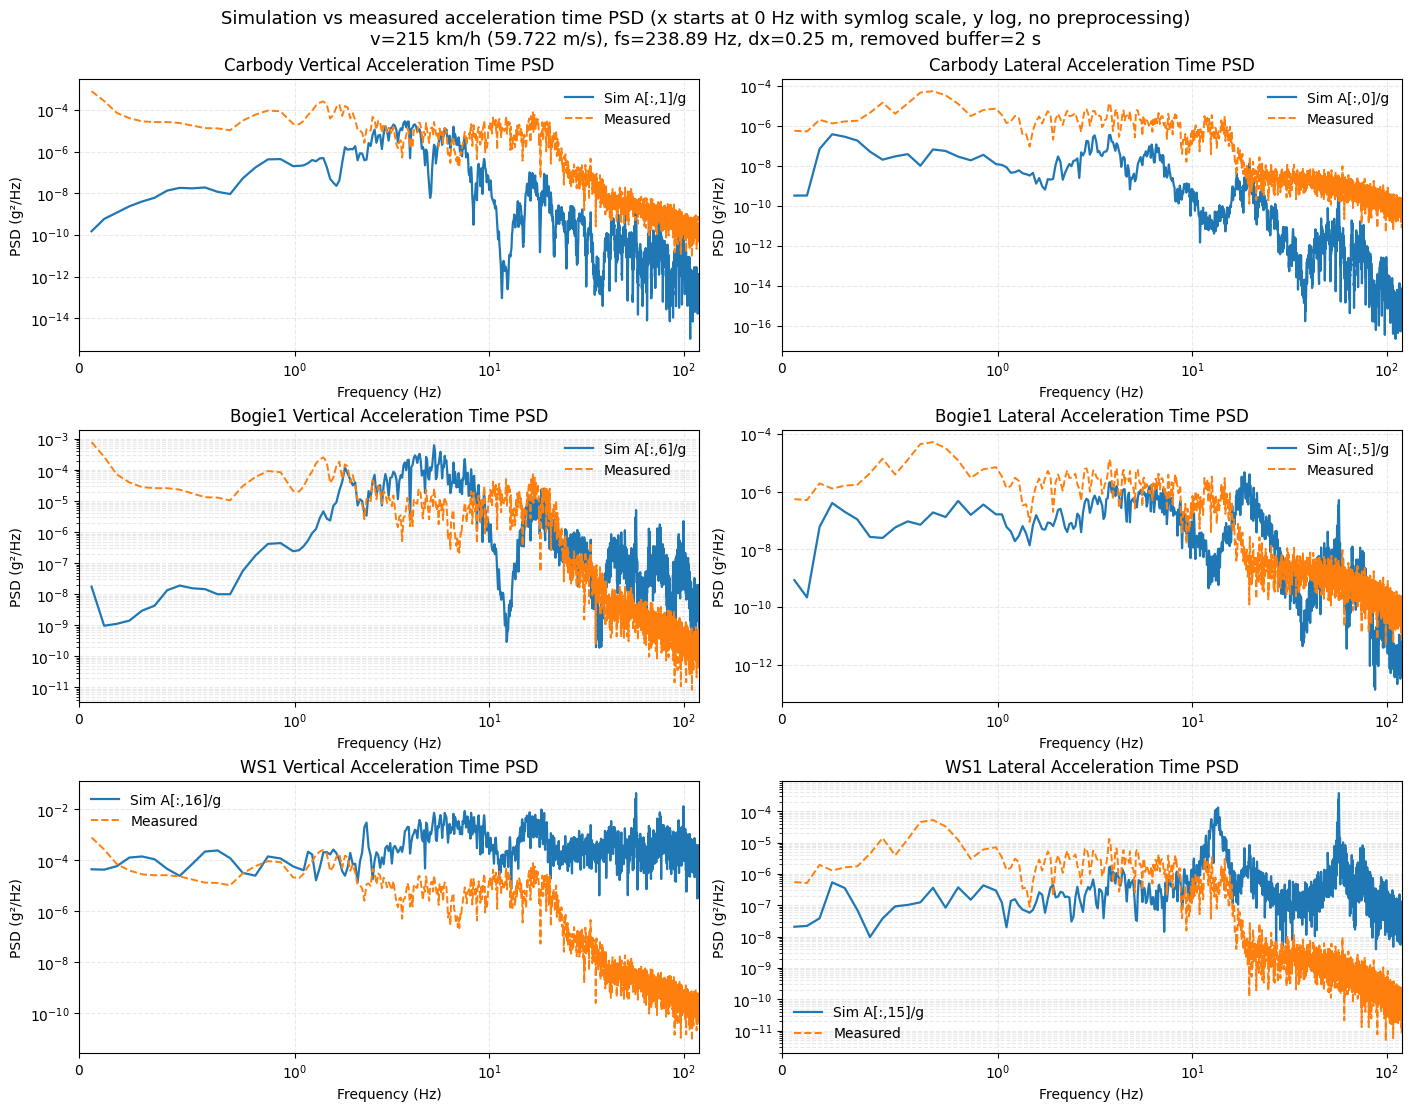

In [21]:
# 新增：时间频率 PSD 对比图（横坐标从 0 Hz 开始，采用 symlog 对数形式；纵坐标 log）
from scipy.signal import welch
import json

params_path = result_file.with_name('argparse_params.json')
with open(params_path, 'r', encoding='utf-8') as f:
    params = json.load(f)

vx_set = params.get('vx_set')
vx_kmh = float(vx_set[0] if isinstance(vx_set, list) else vx_set)
v_mps = vx_kmh / 3.6
if v_mps <= 0:
    raise ValueError('速度必须大于 0，无法将空间采样换算为时间采样。')

def welch_time_psd_no_preprocess(y, dx_m, v_mps, nperseg=None):
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(y)
    if finite.sum() < 8:
        return np.array([]), np.array([]), np.nan
    y = y.copy()
    y[~finite] = np.interp(np.flatnonzero(~finite), np.flatnonzero(finite), y[finite])
    y = y - np.mean(y)
    fs_time = float(v_mps) / float(dx_m)
    if nperseg is None:
        nperseg = min(4096, _next_lower_power_of_two(len(y)))
    nperseg = int(max(8, min(nperseg, len(y))))
    freq, psd = welch(
        y, fs=fs_time, window='hann', nperseg=nperseg,
        noverlap=nperseg // 2, detrend=False
    )
    return freq, psd, fs_time

fig, axes = plt.subplots(len(components), 2, figsize=(14, 11), constrained_layout=True)
fs_time_last = np.nan
dx_m_last = np.nan

for row, (z_dof, y_dof, part_name, z_tag, y_tag) in enumerate(components):
    sim_vert_g = A_use[:, z_dof] / 9.81
    sim_lat_g = A_use[:, y_dof] / 9.81

    for col, (sim_sig, meas_sig, direction, tag) in enumerate([
        (sim_vert_g, meas_acc_vert, 'Vertical', z_tag),
        (sim_lat_g, meas_acc_lat, 'Lateral', y_tag),
    ]):
        x_grid, sim_grid, meas_grid, dx_m = resample_pair_to_common_grid(
            sim_mileage_km, sim_sig, meas_mileage_km, meas_sig
        )
        f_sim, psd_sim, fs_time = welch_time_psd_no_preprocess(sim_grid, dx_m, v_mps)
        f_meas, psd_meas, _ = welch_time_psd_no_preprocess(meas_grid, dx_m, v_mps)
        fs_time_last = fs_time
        dx_m_last = dx_m

        ax = axes[row, col]
        keep_sim = f_sim > 0
        keep_meas = f_meas > 0
        ax.plot(f_sim[keep_sim], psd_sim[keep_sim] + 1e-30, lw=1.6, label=f'Sim {tag}')
        ax.plot(f_meas[keep_meas], psd_meas[keep_meas] + 1e-30, lw=1.4, ls='--', label='Measured')
        ax.set_xscale('symlog', linthresh=1.0, linscale=1.0)
        ax.set_yscale('log')
        ax.set_xlim(left=0.0, right=0.5 * fs_time)
        ax.set_title(f'{part_name} {direction} Acceleration Time PSD')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('PSD (g²/Hz)')
        ax.grid(True, which='both', alpha=0.28, ls='--')
        ax.legend(frameon=False)

fig.suptitle(
    f'Simulation vs measured acceleration time PSD (x starts at 0 Hz with symlog scale, y log, no preprocessing)\n'
    f'v={vx_kmh:g} km/h ({v_mps:.3f} m/s), fs={fs_time_last:.2f} Hz, dx={dx_m_last:.4g} m, removed buffer={buffer_time_s:g} s',
    fontsize=13
)

out_png = out_dir / 'accel_time_psd_x0_symlog_no_preprocess.png'
fig.savefig(out_png, dpi=300, bbox_inches='tight')
print(f'保存图像: {out_png}')
plt.show()
    